# **This notebook was meant to be used in [Google Colab](https://colab.research.google.com/) please upload this to your personal Colab directory**

To accomplish this:
1.  Download the notebook as an '.ipynb' file.
2.  Click the link to "***Google Colab***" above.
  a.  When Google Colab opens, click the ***Upload*** tab.
  b.  Choose the '.ipynb' file downloaded in step 1.

#**Tutorial: Accessing NWS Storm Data Using Parquet and DuckDB**

In this short tutorial, you will learn how to:

* Efficiently retrieve and display NWS Storm Data.
* Export retrieved Storm Data to a CSV.
* Save generated CSV locally.

This notebook employs the [DuckDB Python API](https://duckdb.org/docs/api/python/overview) to access  
National Weather Service (NWS) Storm Data stored in a Google Cloud bucket.  
This data may also be found on the National Center of Environmental Information ([NCEI](https://www.ncei.noaa.gov/))  
Storm Events Database ([SED website](https://www.ncei.noaa.gov/access/storm-events-database)), where Storm Data can be filtered using a geospatial application,  
state/area lookup, or a narrative text search. Bulk downloads of NWS Storm Data  
are also available on the [SED website bulk data download](https://www.ncei.noaa.gov/access/storm-events-database/bulk-data).

---

*This script was last revised on September 4th, 2025.*

---

### We will first ensure all needed Python libraries are installed


In [ ]:
! pip install pandas duckdb -q

###**Importing and Setting Sources**
Now we will:
- Import any needed Python libraries
- Set our duckdb connection to Google Cloud Public Access
- Establish variables for the 3 different
Storm Events Database data files.

In [ ]:
import os
import pprint

import duckdb
import pandas as pd

# We use this to indicate we are pulling data with Duckdb
# From a Public Google Cloud Bucket
duckdb.sql("SET s3_endpoint='storage.googleapis.com'")

# Here we set variables that can be reused to the paths for the
# different Storm Events Database datatypes.
details_bucket_path = 'gs://noaa-ncei-ipg/notebooks/data/stormevents/storm_events_database_details/*/*.parquet'
locations_bucket_path = 'gs://noaa-ncei-ipg/notebooks/data/stormevents/storm_events_database_locations.parquet'
fatalities_bucket_path = 'gs://noaa-ncei-ipg/notebooks/data/stormevents/storm_events_database_fatalities.parquet'

###**Storm Event Database Data Types**
There are 3 types of data tables for Storm Events Database
- Details: contains all of the primary storm event information such as event type, state, year,  
county and many more values.
- Locations: contains the locations data such as lat/lon.
- Fatalities: contains the fatalities data such as age, sex and many more.

###**Retrieve and Display NWS Storm Data by Year and Event Type**

In the following code blocks, we will retrieve and display select NWS Storm Data by defining filters.  
Let's start by searching for all recorded avalanches occuring in the United States in 2016.

In [ ]:
# Retrieve yearly Storm Data
storm_query_avalanche = duckdb.sql(f"""
            SELECT *
            FROM read_parquet('{details_bucket_path}',
            hive_partitioning=true, union_by_name=true) as details
            WHERE
               details.YEAR = 2016 AND
               details.EVENT_TYPE = 'Avalanche';""")

# Display retrieval using a pandas DataFrame
storm_query_avalanche_df = storm_query_avalanche.to_df()
print('This is the number of avalanche records:',
      storm_query_avalanche_df.shape[0])

# Calling Head on the Dataframe shows the first 5 records
storm_query_avalanche_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

This is the number of avalanche records: 30


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,YEAR
0,201601,24,1230,201601,24,1230,101830.0,608906,WASHINGTON,53.0,...,None,None,NaN,NaN,NaN,NaN,"Mark Panthen, 36, of Bellingham, died Sunday a...","Mark Panthen, 36, of Bellingham, died Sunday a...",CSV,2016
1,201601,29,1028,201601,29,1127,102239.0,611134,OREGON,41.0,...,None,None,NaN,NaN,NaN,NaN,An incoming front brought high winds to some l...,The Rock Creek RAWS recorded a gust to 58 mph ...,CSV,2016
2,201601,16,1417,201601,16,1600,103117.0,616171,ALASKA,2.0,...,None,None,NaN,NaN,NaN,NaN,Low pressure in the North Pacific brought stro...,A snowboarder triggered an avalanche on Skyscr...,CSV,2016
3,201602,18,700,201602,18,700,103727.0,620099,CALIFORNIA,6.0,...,None,None,NaN,NaN,NaN,NaN,A potent cold front brought heavy snow with mo...,Two avalanches hit Alpine Meadows Road the mor...,CSV,2016
4,201602,15,1300,201602,15,1500,103316.0,617484,IDAHO,16.0,...,None,None,NaN,NaN,NaN,NaN,An avalanche blocked a portion of Highway 75 n...,An avalanche blocked a portion of Highway 75 n...,CSV,2016


It should be noted that `BEGIN_YEARMONTH` and `END_YEARMONTH`have the format YYYYMM (4 digit year, 2 digit day), where as `DD` has the format of a 2 digit day, and `YEAR` is a 4 digit year, YYYY.  Additionally, time is noted as `BEGIN_TIME` and `END_TIME` has the format of HHMM, 2 digit hour, 2 digit minute.

In addition to filtering by `YEAR` and `EVENT_TYPE`,  
queries may also be created using a combination of the parameters. These parameters are described in the [NWS Storm Data documentation](https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/Storm-Data-Bulk-csv-Format.pdf)).

In [ ]:
# Display list of available, filterable details columns
details_table_columns_list = storm_query_avalanche_df.columns.to_list()
details_table_columns_list.sort()
# just showing the first 5 columns
pprint.pprint(details_table_columns_list[:5])
# to show all columns use this instead
#pprint.pprint(details_table_columns_list)

['BEGIN_AZIMUTH', 'BEGIN_DATE_TIME', 'BEGIN_DAY', 'BEGIN_LAT', 'BEGIN_LOCATION']


For example, let's generate a query for tornadoes of magnitude 3 and above on the  
[Fujita Tornado Damage Scale](https://www.spc.noaa.gov/faq/tornado/f-scale.html) occuring in Kansas in the 1990s.

In [ ]:
# Retrieve Torndado Storm data for the 1990s and using
# Tornado F scale values >=F3 and <=F5
storm_query_torn = duckdb.sql(f"""
            SELECT *
            FROM read_parquet('{details_bucket_path}',
            hive_partitioning=true, union_by_name=true) as details
            WHERE
               details.EVENT_TYPE = 'Tornado' AND
               details.STATE = 'KANSAS' AND
               details.TOR_F_SCALE IN ['F3','F4','F5'] AND
               details.BEGIN_YEARMONTH > 199000 AND
               details.BEGIN_YEARMONTH < 200000;""")

# Display retrieval using a DataFrame
storm_query_torn_df = storm_query_torn.to_df()
storm_query_torn_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,YEAR
0,199004,25,1735,199004,25,1735,NaN,10034351,KANSAS,20.0,...,None,None,38.78,-99.55,39.12,-99.32,None,None,PUB,1990
1,199005,24,1814,199005,24,1814,NaN,10036624,KANSAS,20.0,...,None,None,38.48,-97.37,38.50,-97.03,None,None,PUB,1990
2,199004,25,1700,199004,25,1700,NaN,10034347,KANSAS,20.0,...,None,None,38.62,-99.73,38.68,-99.70,None,None,PUB,1990
3,199004,25,1714,199004,25,1714,NaN,10034349,KANSAS,20.0,...,None,None,38.68,-99.70,38.78,-99.55,None,None,PUB,1990
4,199005,24,1714,199005,24,1714,NaN,10036623,KANSAS,20.0,...,None,None,38.52,-97.90,38.48,-97.37,None,None,PUB,1990


###**Using Dates in your query**
In the previous query we used *BEGIN_YEARMONTH*  
In the next query we will use *BEGIN_DATE_TIME* which can be used for  
smaller ranges or single day queries.


In [ ]:
# The same query as above but using BEGIN_DATE_TIME
# rather than BEGIN_YEARMONTH
storm_query_torn = duckdb.sql(f"""
            SELECT *
            FROM read_parquet('{details_bucket_path}',
            hive_partitioning=true, union_by_name=true) as details
            WHERE
               details.EVENT_TYPE = 'Tornado' AND
               details.STATE = 'KANSAS' AND
               details.TOR_F_SCALE IN ['F3','F4','F5'] AND
               strptime(details.BEGIN_DATE_TIME, '%d-%b-%y %H:%M:%S')
               BETWEEN DATE '1990-01-01' AND DATE '2000-01-01'""")

# Display retrieval using a DataFrame
storm_query_torn_df = storm_query_torn.to_df()
storm_query_torn_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,YEAR
0,199004,25,1735,199004,25,1735,NaN,10034351,KANSAS,20.0,...,None,None,38.78,-99.55,39.12,-99.32,None,None,PUB,1990
1,199005,24,1814,199005,24,1814,NaN,10036624,KANSAS,20.0,...,None,None,38.48,-97.37,38.50,-97.03,None,None,PUB,1990
2,199004,25,1700,199004,25,1700,NaN,10034347,KANSAS,20.0,...,None,None,38.62,-99.73,38.68,-99.70,None,None,PUB,1990
3,199004,25,1714,199004,25,1714,NaN,10034349,KANSAS,20.0,...,None,None,38.68,-99.70,38.78,-99.55,None,None,PUB,1990
4,199005,24,1714,199005,24,1714,NaN,10036623,KANSAS,20.0,...,None,None,38.52,-97.90,38.48,-97.37,None,None,PUB,1990


In [ ]:
# Lets get all the EVENT_IDs from the details table from our last
# query and use them to find an event in wich there were multiple fatalties.
tornado_ids = storm_query_torn_df['EVENT_ID'].unique().tolist()

In [ ]:
# Query the fatalities tables using the EVENT_IDs from the last query.
tornado_fatalities = duckdb.sql(f"""
            SELECT *
            FROM read_parquet('{fatalities_bucket_path}',
            union_by_name=True) as fatalities
            WHERE
               fatalities.EVENT_ID IN ({','.join(map(str, tornado_ids))})""")
tornado_fatalities_df = tornado_fatalities.to_df()


In [ ]:
# Here we will find the EVENT_ID values with multiple
# fatalities, we'll extract the EVENT_ID with the most
# fatalities and use it in our next query.
mutliple_fatalities_event_id = (tornado_fatalities_df
                                .value_counts()
                                .reset_index()
                                .sort_values('count', ascending=False)['EVENT_ID'].tolist()[0])

###**Joining the Details Table and Fatalities Table**
In this next cell we use LEFT JOIN to join the two tables and return  
EVENT_ID, STATE and CZ_NAME from the Details table and all the  
values from the Fatalities table. If we only queried the Details table  
using this EVENT_ID it would return a single row, but here with the LEFT_JOIN,  
our results will have multiple rows, with the values from the Details table
being repeated.

In [ ]:
# Joining details and fatalities for a single EVENT_ID
storm_query_torn_with_fatalities = duckdb.sql(f"""
            SELECT
            details.EVENT_ID,
            details.STATE,
            details.CZ_NAME,
            fatalities.*
            FROM read_parquet('{details_bucket_path}',
            hive_partitioning=true, union_by_name=true) as details
            LEFT JOIN read_parquet('{fatalities_bucket_path}') as fatalities
            ON details.EVENT_ID = fatalities.EVENT_ID
            WHERE
               details.EVENT_ID = {mutliple_fatalities_event_id}""")
storm_query_torn_with_fatalities.to_df()

,EVENT_ID,STATE,CZ_NAME,FAT_YEARMONTH,FAT_DAY,FAT_TIME,FATALITY_ID,EVENT_ID_1,FATALITY_TYPE,FATALITY_DATE,FATALITY_AGE,FATALITY_SEX,FATALITY_LOCATION,EVENT_YEARMONTH
0,5690169,KANSAS,SEDGWICK,199905,3,0,1003356,5690169,D,05/03/1999 12:00:00,27.0,M,Mobile/Trailer Home,199905.0
1,5690169,KANSAS,SEDGWICK,199905,3,0,1003357,5690169,D,05/03/1999 12:00:00,43.0,F,Outside/Open Areas,199905.0
2,5690169,KANSAS,SEDGWICK,199905,3,0,1003358,5690169,D,05/03/1999 12:00:00,1.0,M,Outside/Open Areas,199905.0
3,5690169,KANSAS,SEDGWICK,199905,3,0,1003359,5690169,D,05/03/1999 12:00:00,83.0,M,Mobile/Trailer Home,199905.0
4,5690169,KANSAS,SEDGWICK,199905,3,0,1003360,5690169,D,05/03/1999 12:00:00,68.0,M,Mobile/Trailer Home,199905.0
5,5690169,KANSAS,SEDGWICK,199905,23,0,1003361,5690169,D,05/23/1999 12:00:00,78.0,M,Mobile/Trailer Home,199905.0


###**Export DuckDB Query to a CSV**


####**Method 1: Using a SQL Statement**

Here is a quick way to save a CSV using the DuckDB Python API.  
This method is recommended if you will not be conducting any additional data handling in Python.

In [ ]:
# Export the relation to a CSV file here in Colab
storm_query_avalanche.write_csv("stormdata_tutorial_avalanches.csv")

####**Method 2: Using a Pandas Dataframe.**

This method relies on the [pandas library](https://pandas.pydata.org/) to futher manipulate the queried  Storm Data prior to generating a CSV output.  
See the [Polars documentation](https://docs.pola.rs/) for a comparable, alternative library for creating and handling DataFrames.

In this example, we will:

1.   Query the database for flood events occuring in  
US states bordering the Pacific Ocean between 2000 and 2010.
2.   Filter the returned data by the entry source.
3.   Create a histogram of NWS reports by month.
4.   Export our created dataframe to a CSV.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipython-input-2426793673.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flooding_filtered_df ["MONTH"] = flooding_filtered_df['BEGIN_YEARMONTH'] % 100 # define months


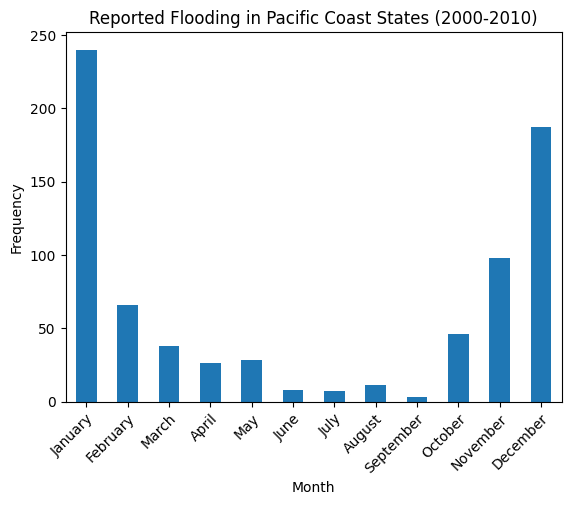

In [ ]:
import matplotlib.pyplot as plt

## Query the database for flooding occuring along the West Coast between 2000 and 2010.
storm_query_hurr = duckdb.sql(f"""
            SELECT *
            FROM read_parquet('{details_bucket_path}',
            hive_partitioning=true, union_by_name=true) as details
            WHERE
               details.EVENT_TYPE = 'Flood' AND
               details.STATE IN ['CALIFORNIA', 'WASHINGTON', 'OREGON'] AND
               details.BEGIN_YEARMONTH > 200000 AND
               details.BEGIN_YEARMONTH < 201000;""")

# Convert to Pandas DataFrame
flooding_df = storm_query_hurr.to_df()

## Filter the returned data by the entry source
flooding_filtered_df = flooding_df.loc[~flooding_df.SOURCE.isin(["BROADCAST MEDIA","Broadcast media"])].copy() # remove broadcast media sources

## Create a histogram of NWS flood reports by month
flooding_filtered_df ["MONTH"] = flooding_filtered_df['BEGIN_YEARMONTH'] % 100 # define months
monthly_counts = flooding_filtered_df.groupby('MONTH').size() # number of events per month

# Plot data, handle labels
fig, ax = plt.subplots()
monthly_counts.plot(kind='bar',ax=ax)
ax.set(
    title='Reported Flooding in Pacific Coast States (2000-2010)',
    xlabel='Month',
    ylabel = 'Frequency')

# Handle xtick labels
month_label = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December']
ax.set_xticklabels(month_label, rotation=45,ha='right',rotation_mode='anchor')

# Show the plot
plt.show()

# Export Dataframe to a CSV here in Colab
flooding_filtered_df.to_csv('stormdata_tutorial_flooding.csv')

###**Save CSV Locally**

Save the `stormdata_tutorial_sql.csv` file to your local computer.  
This may also be done by navigating to the left pane, clicking the folder icon,  
clicking 'Refresh', and right clicking on the file you want to download.  Alternatively, run the two blocks of code below, each time choosing the folder where to save the files.

In [ ]:
from google.colab import files

# Donwload CSV locally
files.download('stormdata_tutorial_avalanches.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('stormdata_tutorial_flooding.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---


###**Credit**

Developers
* Noah Benitez-Nelson (NCEI, Riverside)
* Fred Kellner (NCEI, Riverside)

Reviewers
* Steve Ansari (NCEI)

